## 
    Time period	: 1950 - 2023
    
    location:   s(glost,k=5)  
    
    scale	    1
    shape       1



In [104]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

from scipy.signal import find_peaks, argrelextrema,argrelmax,argrelmin
import scipy.stats as stats
from scipy.stats import genextreme as gev
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv
from copy import copy
pandas2ri.activate()

extRemes = importr("extRemes")
evgam = importr("evgam")
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [105]:
%config InlineBackend.figure_format = 'retina'
plt.style.use("cma.mplstyle")

In [106]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# READ AFI, DJF Temperature and topography FILES

In [62]:
yearb=1950
yeare=2023

files=[f'../AFI/AFIT/AFI_ERA5_{iyear}.nc' for iyear in range(yearb,yeare+1)]

ds=xr.open_mfdataset(files)
ds=ds.sortby('lat')
ds['AFI']=ds['AFI']*5/9.
ds['time']=np.arange(yearb,yeare+1,1)

return_periods=[2, 5, 10, 25, 50, 100]
Tlon=ds.lon.data
Tlat=ds.lat.data

units='degree-days (°C)'

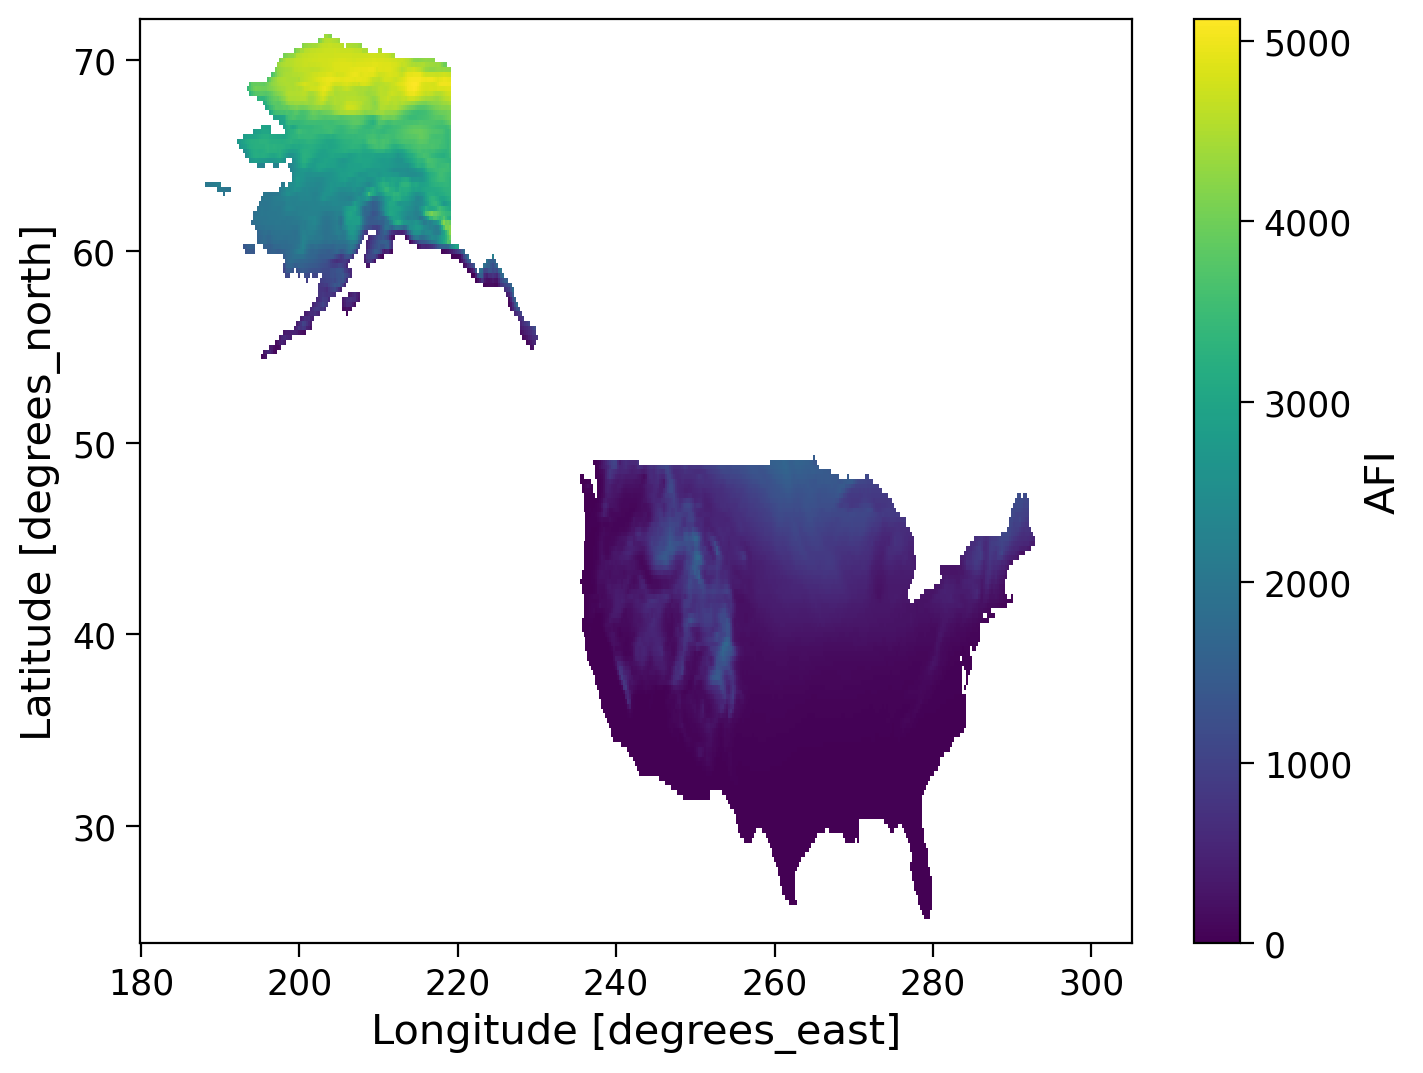

In [63]:
ds['AFI'].mean('time').plot()

# Read GLOST

In [64]:
fileGLOST = '../AFI/NOAA_GLOST_anomaly.csv'
df_glost=pd.read_csv(fileGLOST,skiprows=4)
df_glost['Year']=pd.to_datetime(df_glost['Year'], format='%Y%m')
df_glost=df_glost.rename(columns={'Year': 'time'})

In [65]:
ds_glost=df_glost.set_index(['time']).to_xarray()

In [66]:
def ann_mean(var):
    month_length = var.time.dt.days_in_month
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()
    var_ann = (var*wgts).groupby("time.year").sum()
    return var_ann

In [67]:
annds_glost=ann_mean(ds_glost)
annds_glost=annds_glost.rename({'year':'time'})
annds_glost=annds_glost.sel(time=ds['time'])

# Merge AFI with GLOST

In [68]:
ds=ds.merge({'glost':annds_glost['Anomaly']})

# Reduce domain for testing purpose

In [78]:
lon_min=235;lon_max=293
lat_min=28;lat_max=50

In [79]:
ds=ds.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon=ds.lon.data
Tlat=ds.lat.data

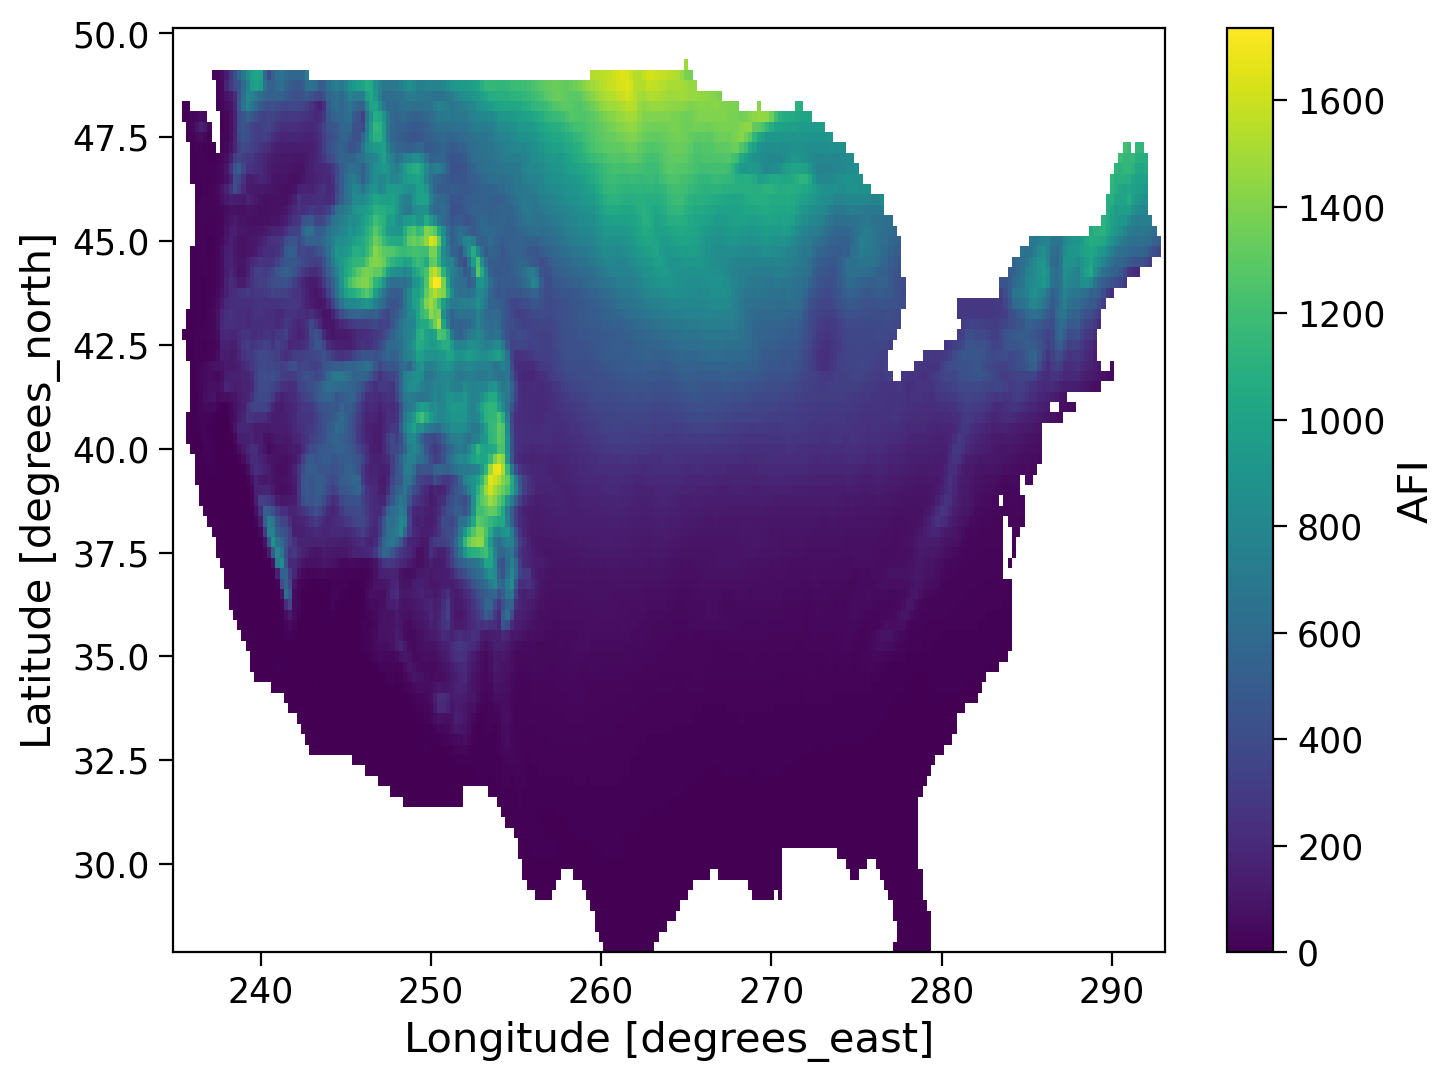

In [80]:
ds['AFI'].mean('time').plot()

# Define EVGAM parameters for smoothness 

In [81]:
# parameters for smoothness 
%R fmla_gev <- list(AFI ~ s(glost,k=5) , ~ 1 , ~ 1)

o{'None': AFI ~ s(glost, k = 5)
, 'None': ~1
, 'None': ~1
, }

# evgam fit_gev and rl100
# through box 20x20pts ~6


In [82]:
Rlocation=xr.zeros_like(ds['AFI'].load())*np.nan
Rshape=xr.zeros_like(ds['AFI'].load())*np.nan
Rscale=xr.zeros_like(ds['AFI'].load())*np.nan
Rrl100=xr.zeros_like(ds['AFI'].load())*np.nan

mask=xr.where(np.isnan(ds['AFI'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)
for ij in range(0,len(idlat)):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=Tlon[ii]
  ilat=Tlat[jj]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  if df.empty == True:
    Rlocation.loc[{'lat':ilat,'lon':ilon}]=-999
    Rscale.loc[{'lat':ilat,'lon':ilon}]=-999
    Rshape.loc[{'lat':ilat,'lon':ilon}]=-999
    Rrl100.loc[{'lat':ilat,'lon':ilon}]=-999
  else:  
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    r_df = ro.conversion.py2rpy(df)
    globalenv['r_df'] = r_df

    # EVGAM model fitting  
    %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
    %R gev_pred <- predict(m_gev, r_df, type = "response")
    %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
    %R -o gev_pred,gev_rl100 # get R data to python

    # Convert R data.frame to xarray
    gev_pred['time']=df['time'].values
    dsgev_pred=gev_pred.set_index(['time']).to_xarray()

    ######
    ######
    gev_rl100['time']=df['time'].values
    dsgev_rl100=gev_rl100.set_index(['time']).to_xarray()
    
    ######
    ######

    Rlocation.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_pred['location'][:]
    Rscale.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_pred['scale'][:]
    Rshape.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_pred['shape'][:]
    Rrl100.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_rl100['q:0.99'][:]


boxes in grey

# Read GEV parameters with scipy.stats.

In [ ]:

file0=f'../AFI/afi_return.fullUSA.gev.1980_2008_KS.nc'
ds0=xr.open_dataset(file0)
ds0=ds0.sortby('lat')
ds0=ds0.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

Slocation = ds0['location']*5/9.
Sshape = ds0['shape']
Sscale = ds0['scale']*5/9.
Srl100 = ds0['return_afi'].sel(return_periods=100)*5/9.

The 100-year return level is expressed in degree-days (C).

In [99]:
from copy import copy
cmap200=copy(cmaps.BlGrYeOrReVi200)
cmap200.set_under('darkgrey', 1.0)

cmapBR=copy(cmaps.ncl_default)
cmapBR.set_under('darkgrey', 1.0)
proj=ccrs.PlateCarree()

# Plot location

<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/3211955555.py:33: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/3211955555.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


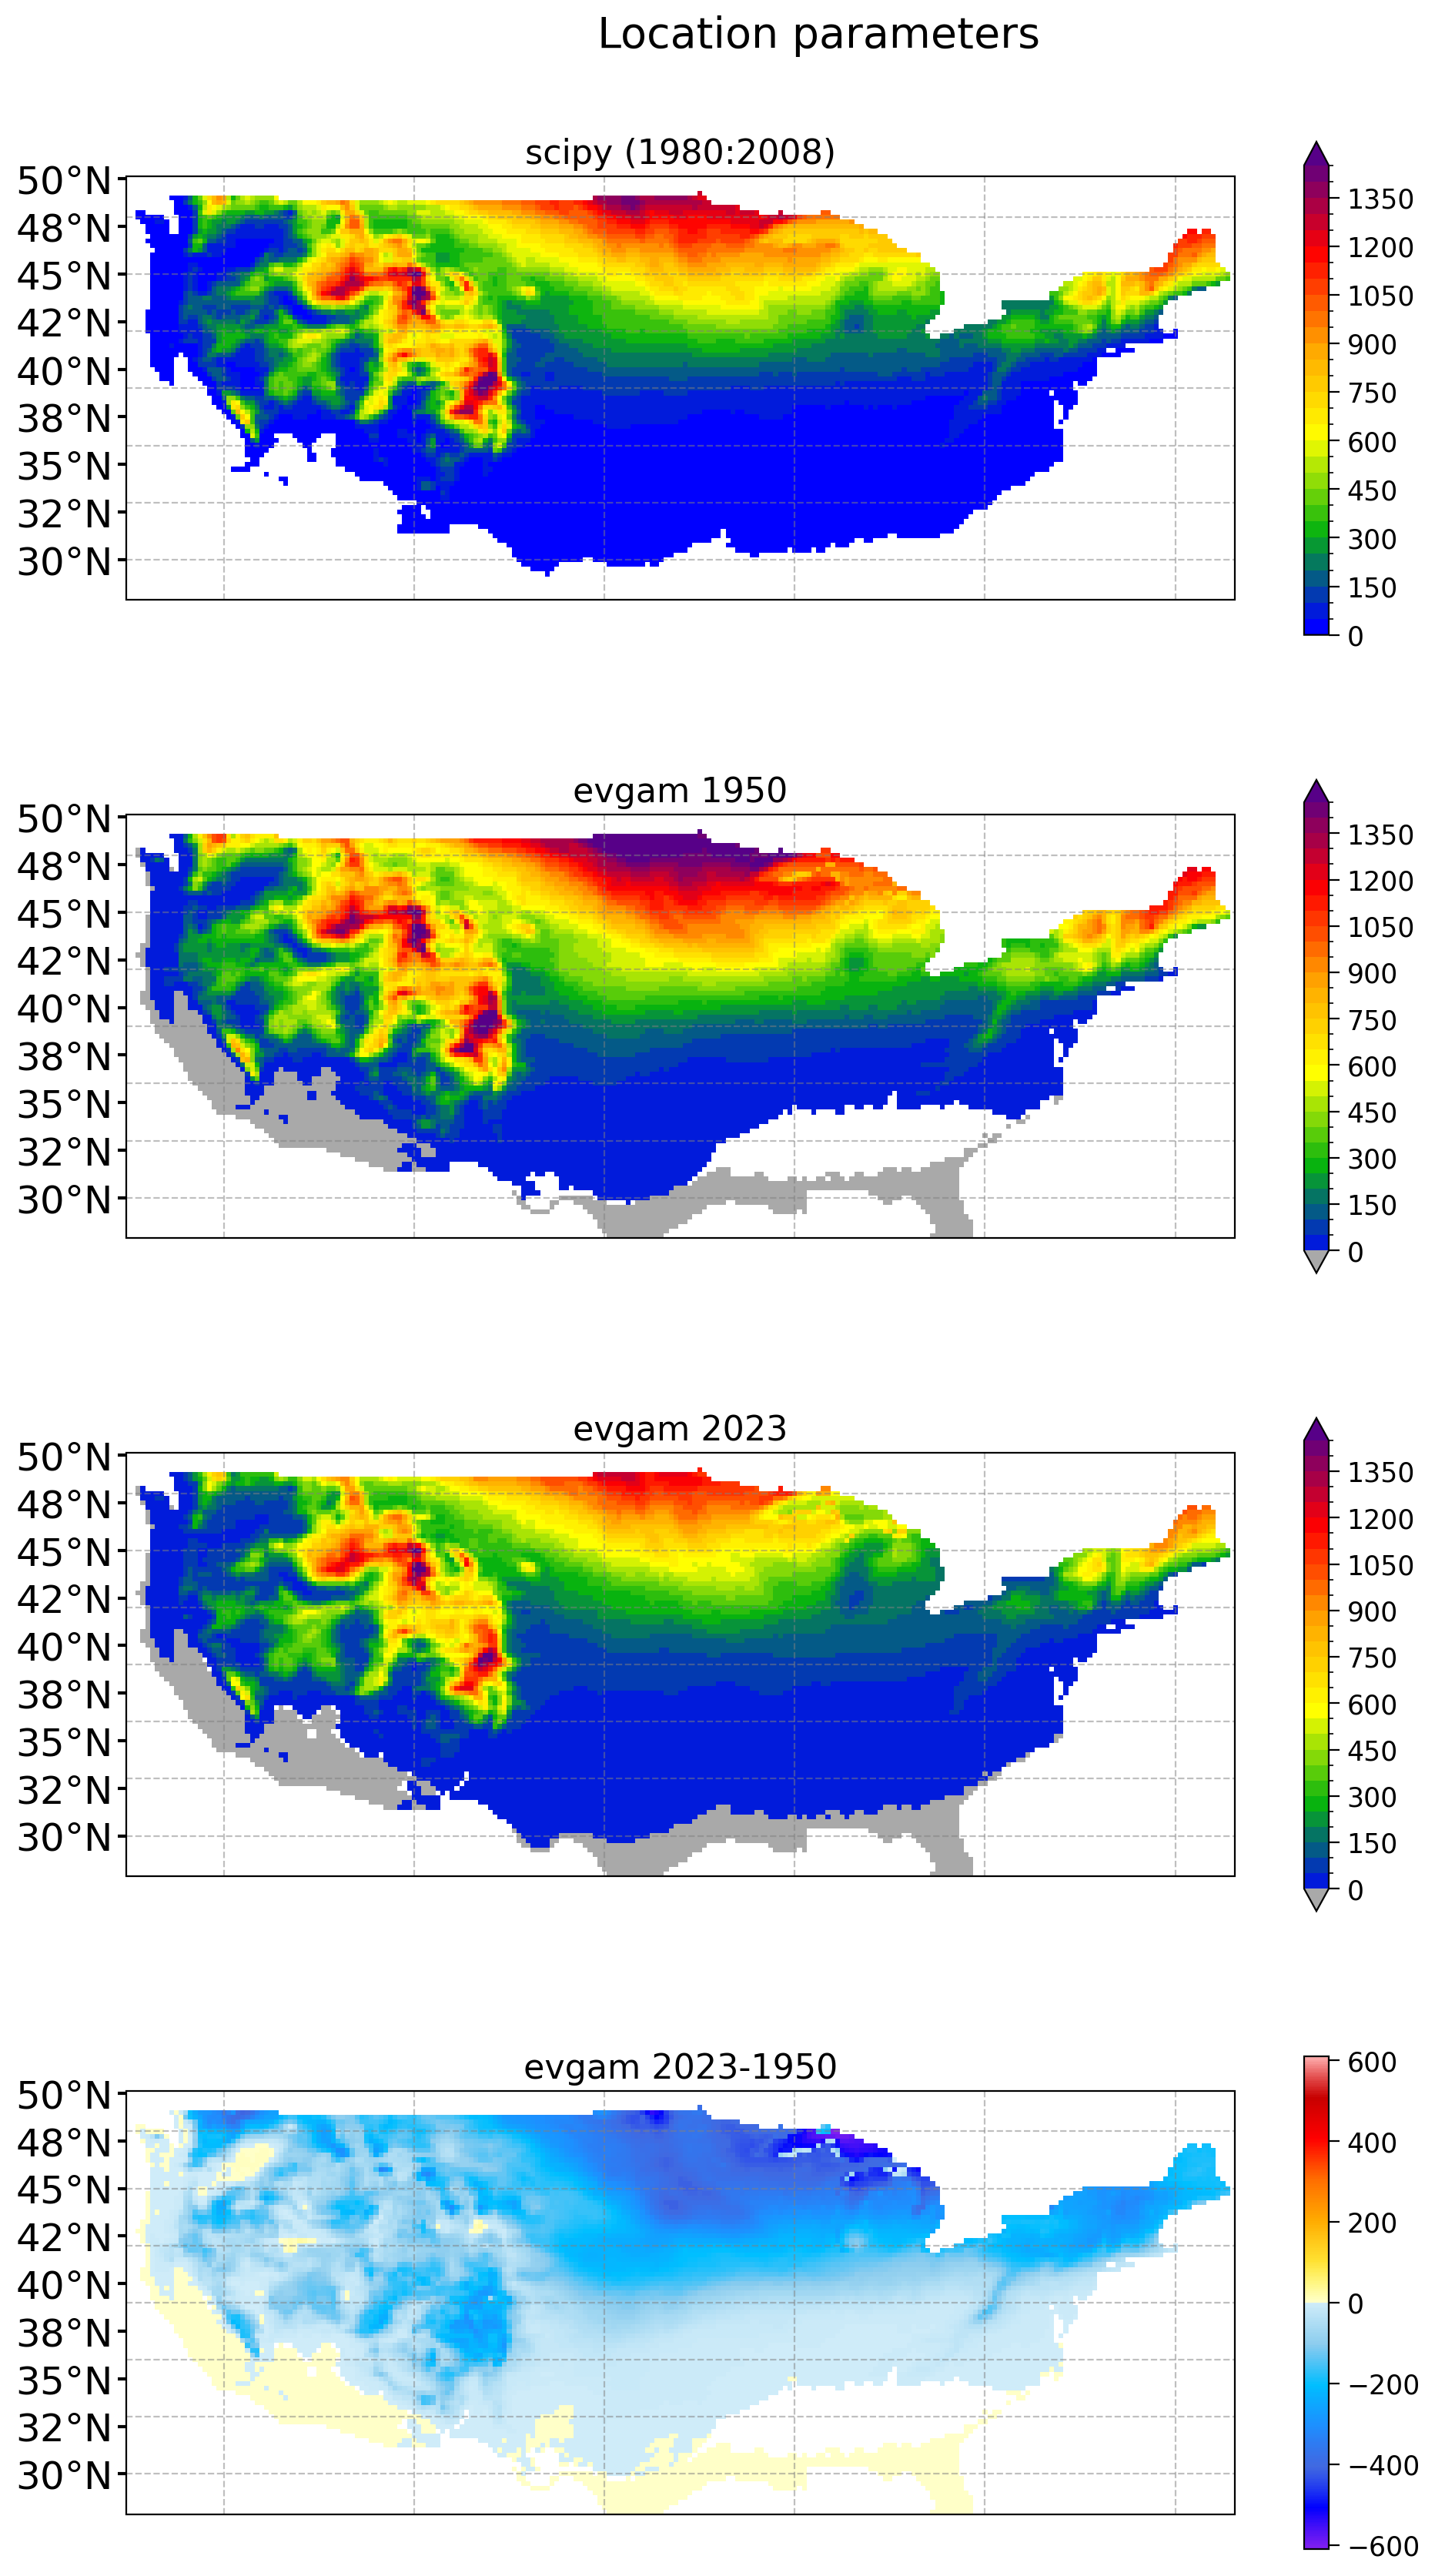

In [100]:

fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(10,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.05,top=0.95, left=0.05,right=0.95,wspace=0.15,hspace=0.1)
ax=ax.flatten()

shrink=0.85
#
#  Location
#
clevs = np.arange(0,1500,50)

Slocation.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rlocation.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rlocation.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rlocation.isel(time=73)-Rlocation.isel(time=0)
data.plot(ax=ax[3],cmap=cmapBR,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.5, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 4: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Location parameters',fontsize=20)    
outfile=f'GEV_NSloc_location.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')


In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.

# Plot Scale

<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/3038032802.py:33: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/3038032802.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


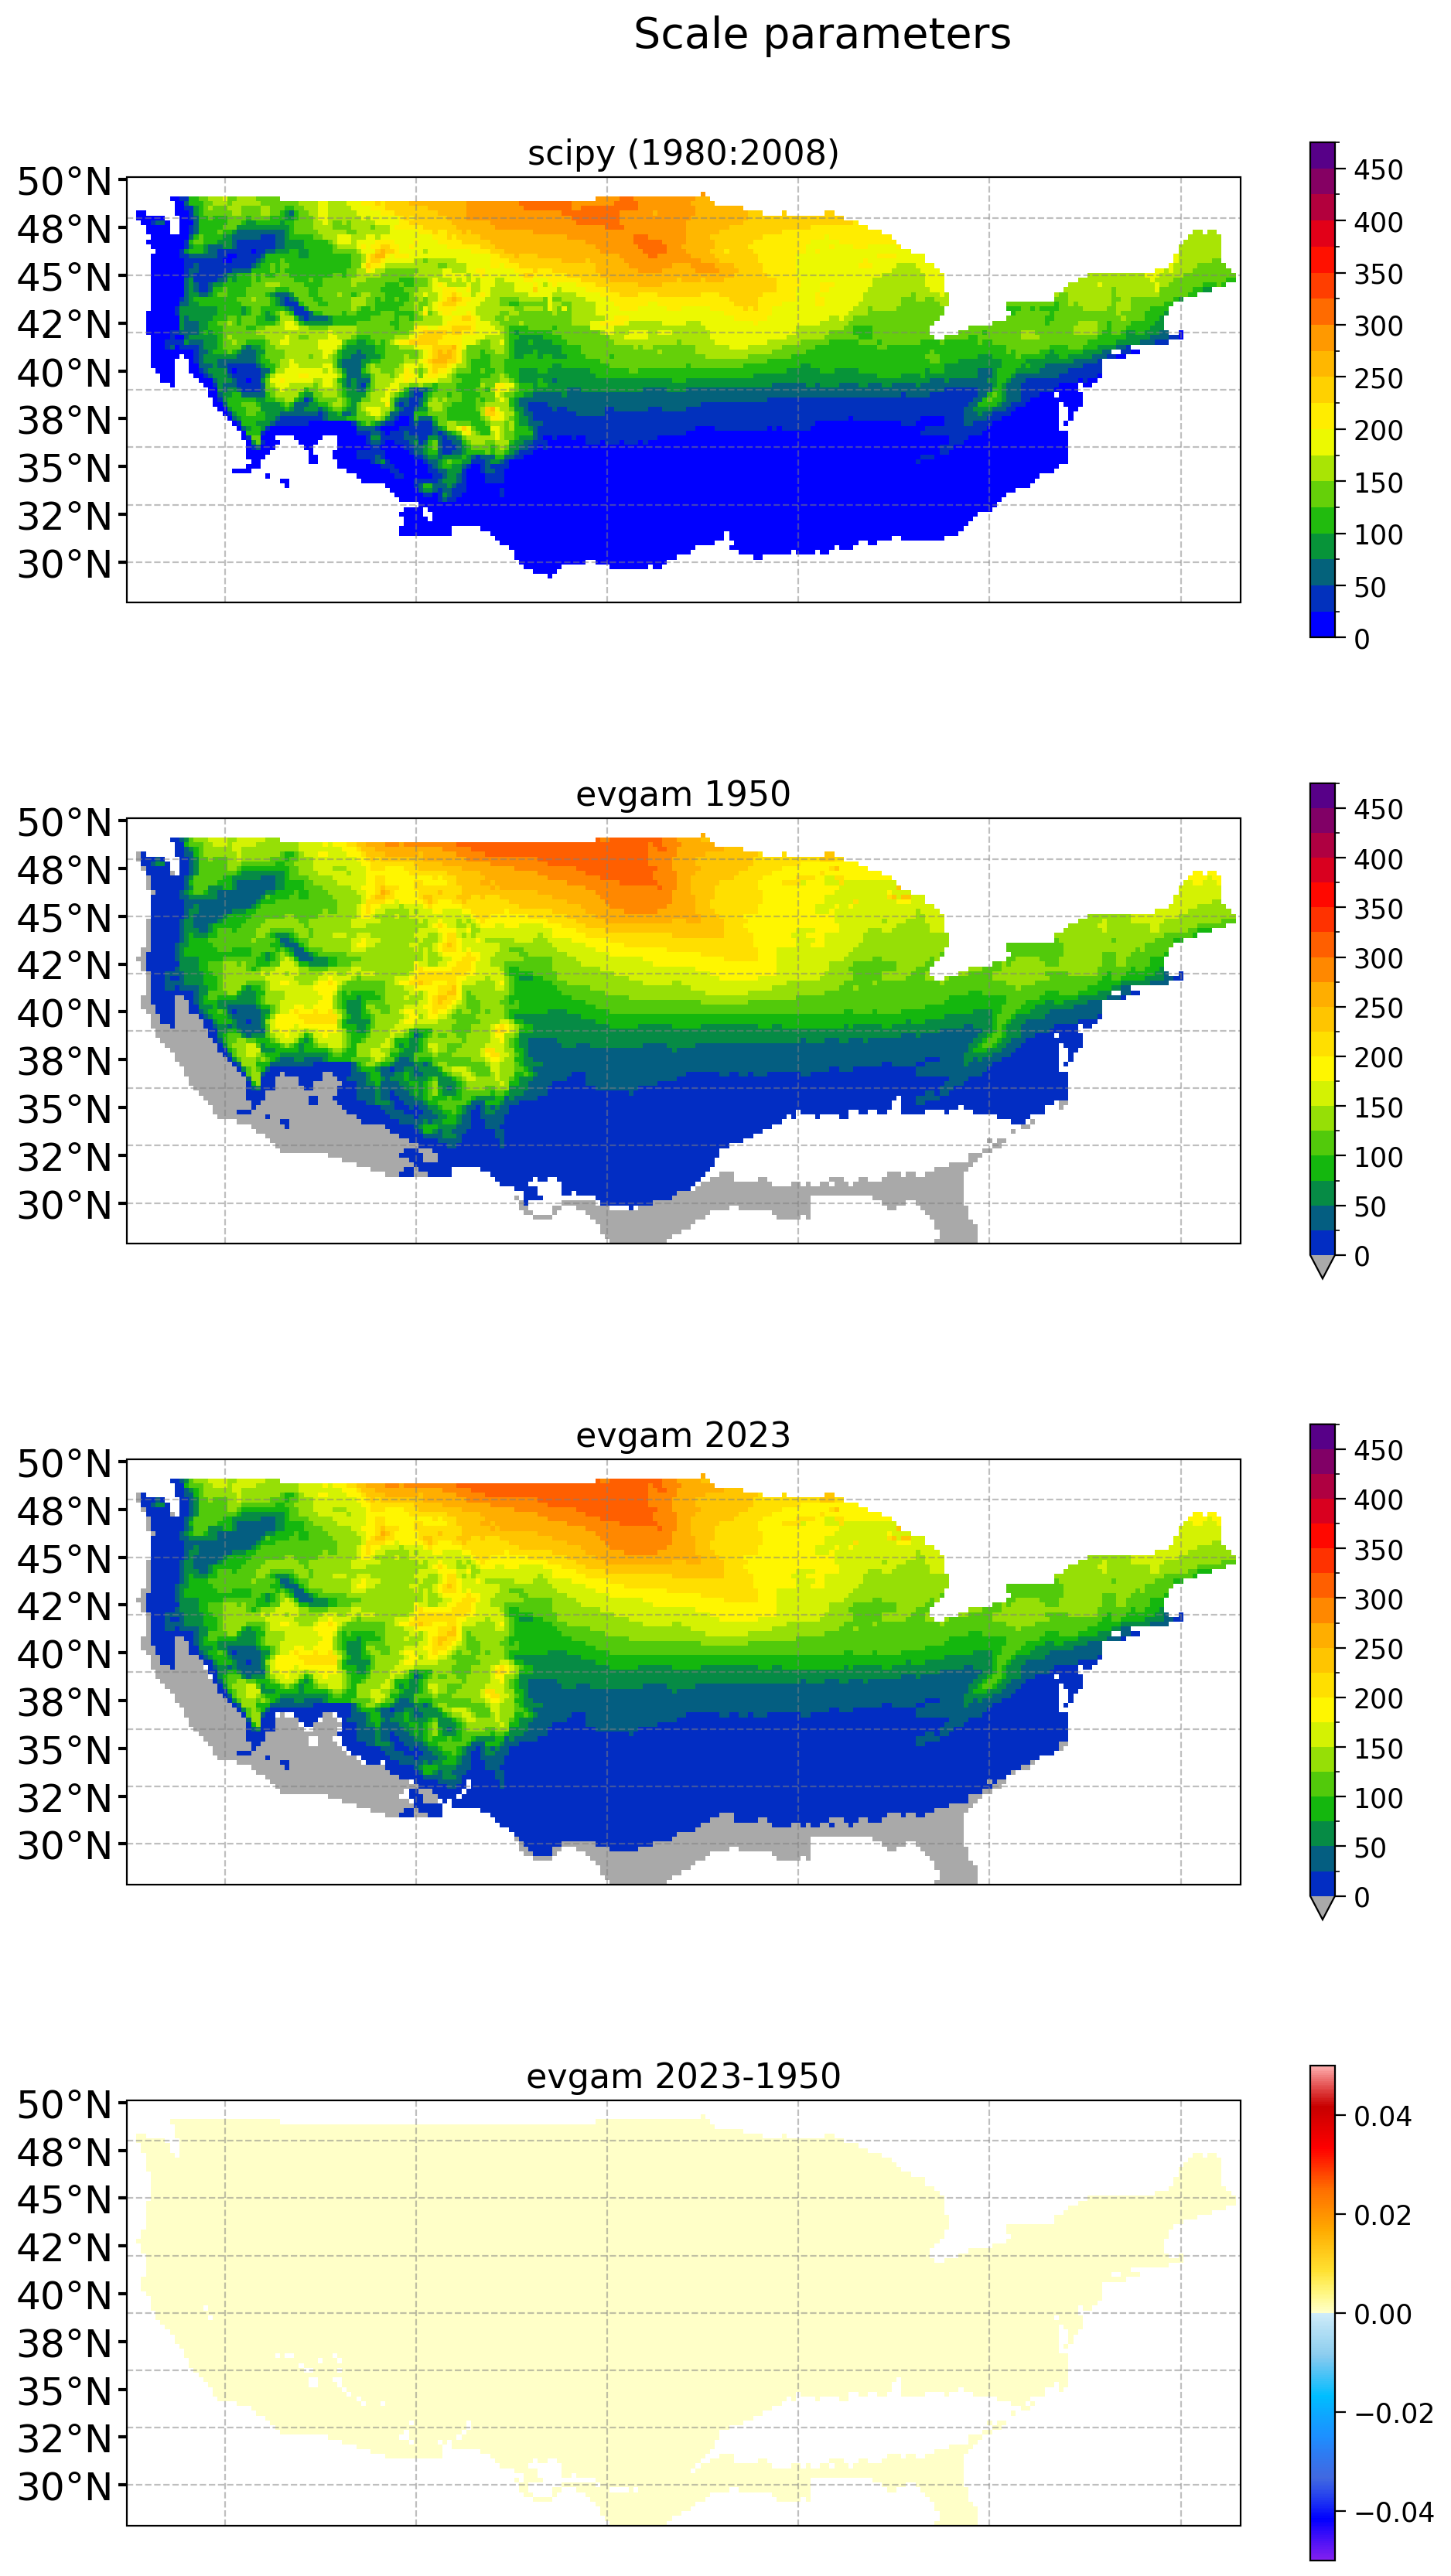

In [101]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(10,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.05,top=0.95, left=0.05,right=0.95,wspace=0.15,hspace=0.1)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,500,25)

Sscale.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rscale.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rscale.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rscale.isel(time=73)-Rscale.isel(time=0)
data.plot(ax=ax[3],cmap=cmapBR,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.5, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 4: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Scale parameters',fontsize=20)    
outfile=f'GEV_NSloc_scale.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.

# Plot Shape

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/3838172999.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/3838172999.py:39: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


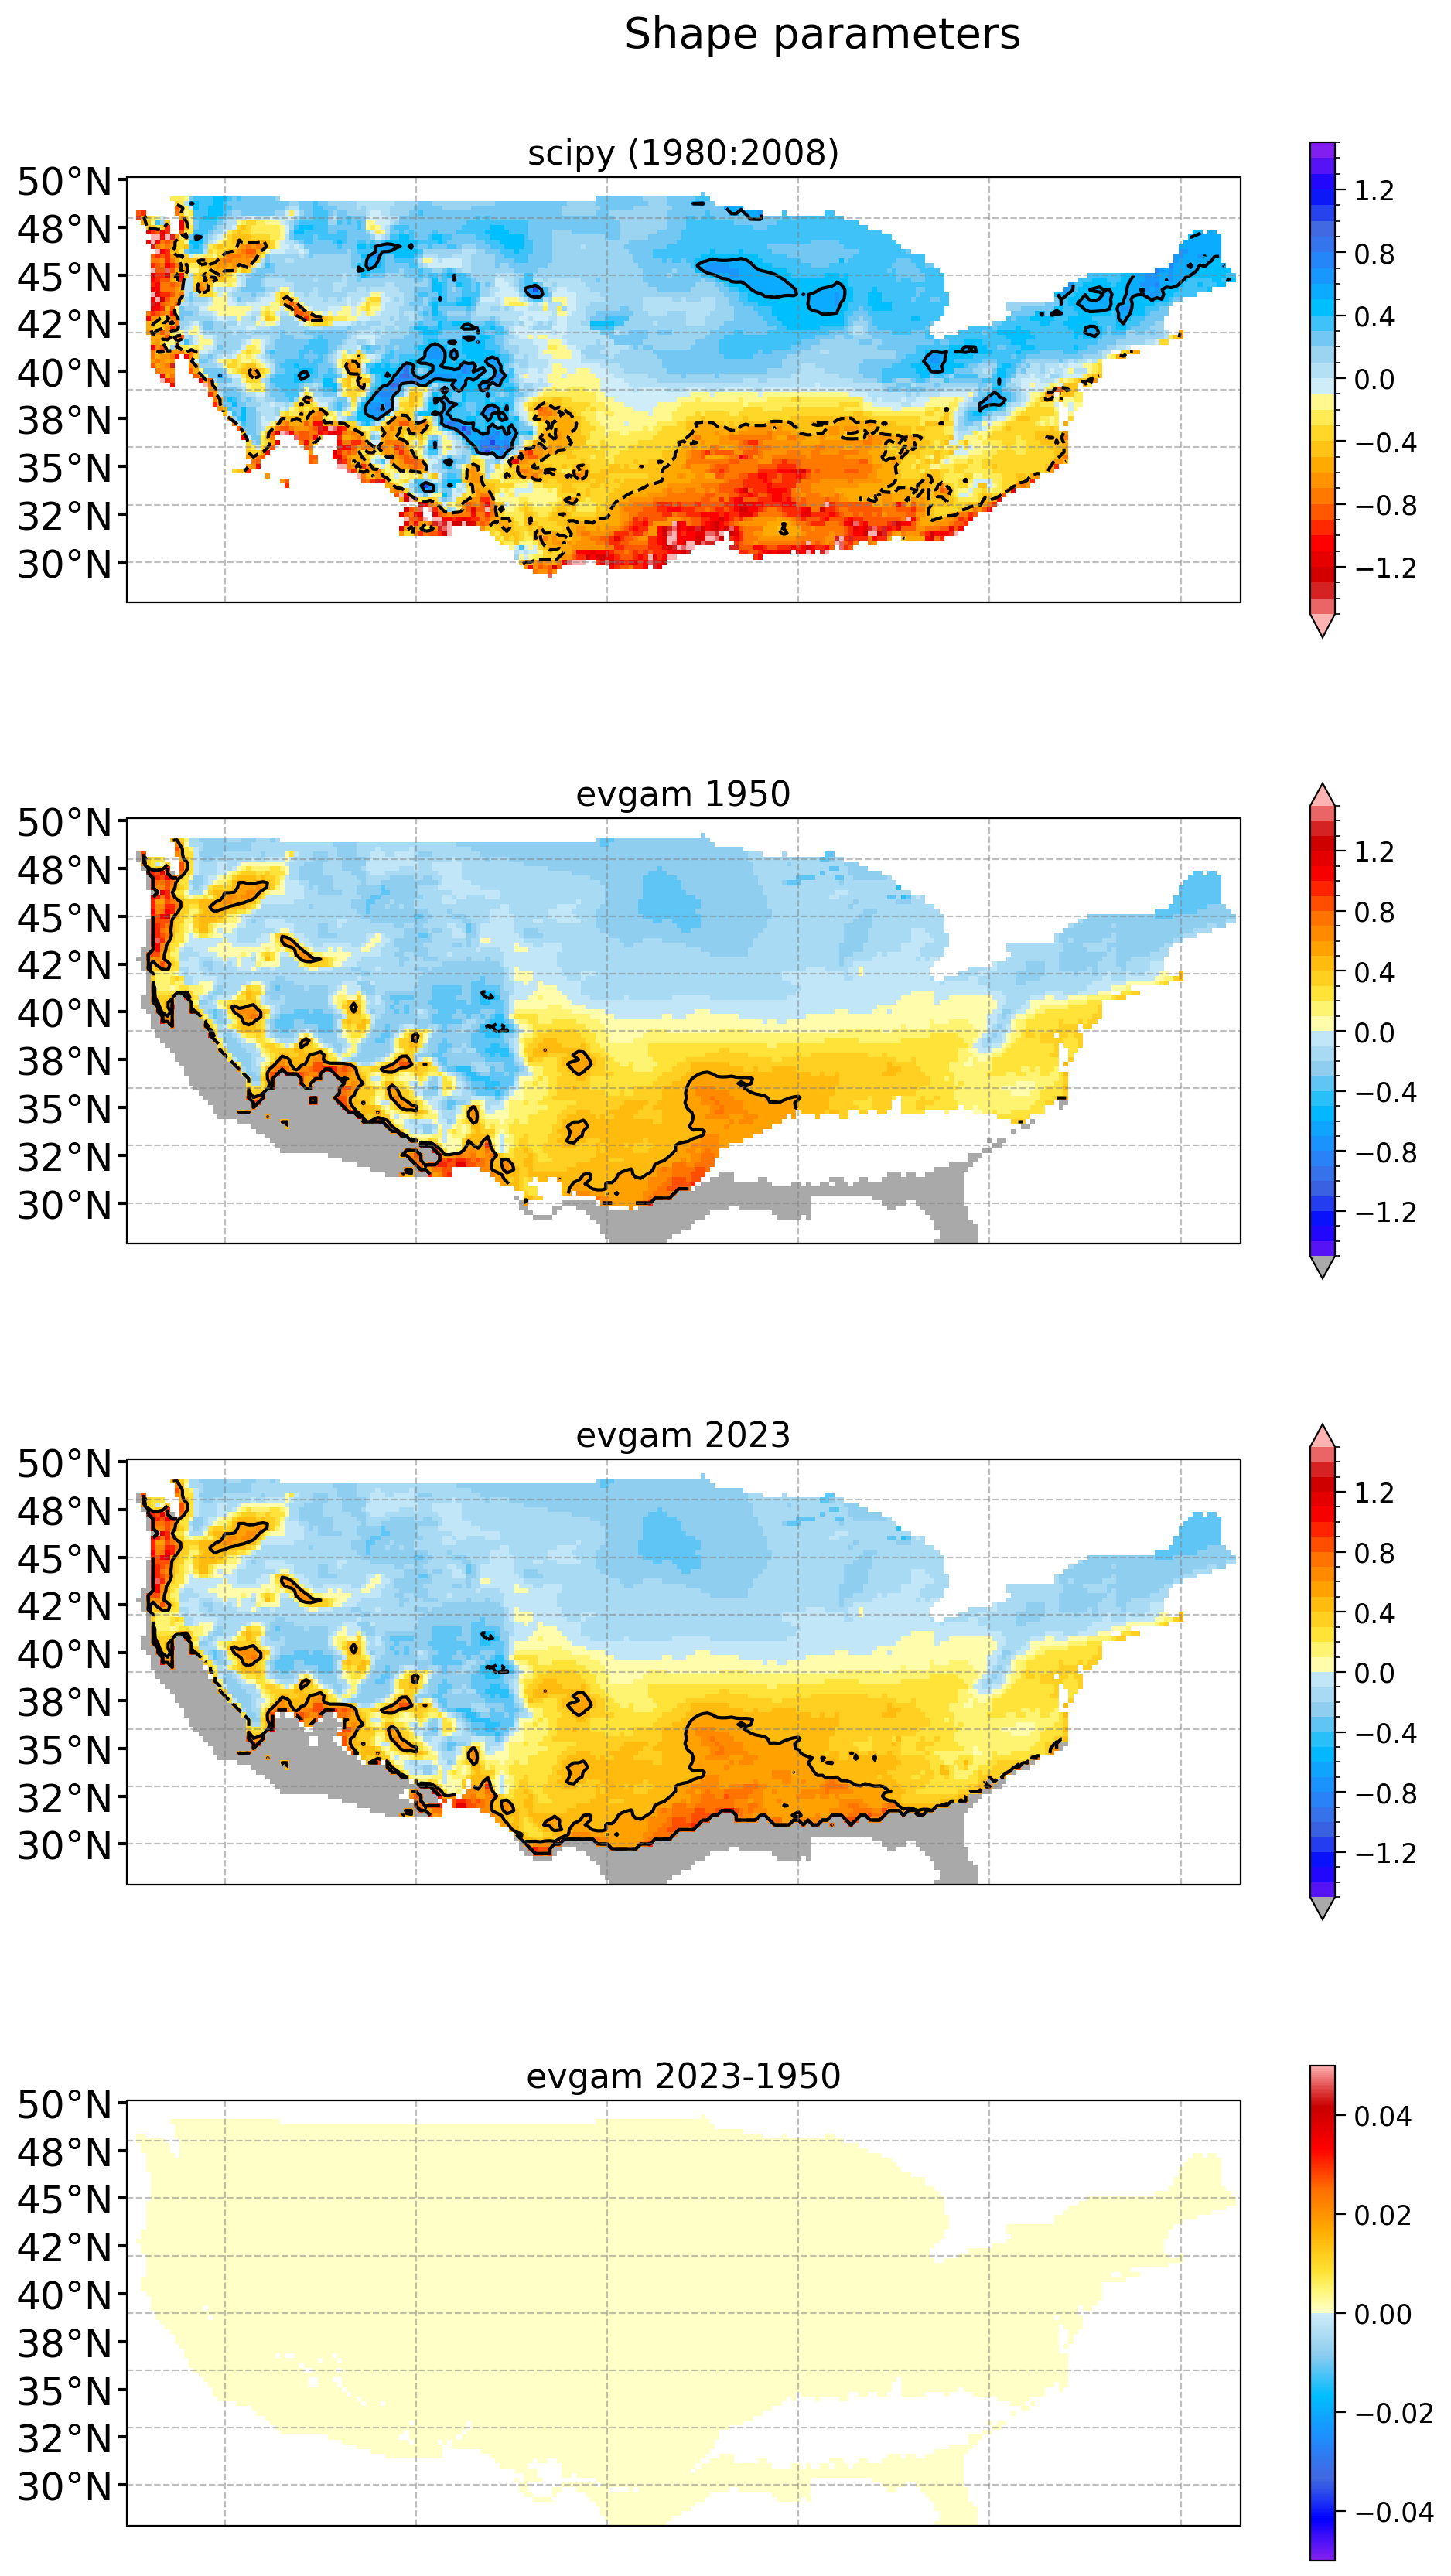

In [114]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(10,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.05,top=0.95, left=0.05,right=0.95,wspace=0.15,hspace=0.1)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(-1.5,1.6,0.1)

Sshape.plot(ax=ax[0],cmap=cmaps.ncl_default_r,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].contour(Sshape['lon'],Sshape['lat'],Sshape,levels=[-0.5,0.5],colors='k')
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rshape.isel(time=0).plot(ax=ax[1],cmap=cmapBR,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=0),levels=[-0.5,0.5],colors='k')
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rshape.isel(time=73).plot(ax=ax[2],cmap=cmapBR,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rshape.isel(time=73)-Rshape.isel(time=0)
data.plot(ax=ax[3],cmap=cmapBR,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.5, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 4: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Shape parameters',fontsize=20)    
outfile=f'GEV_NSloc_shape.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.
The black contours are showing [-0.5,0.5].

# Plot 100y Return Level 

<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/1870123962.py:33: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_66349/1870123962.py:36: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


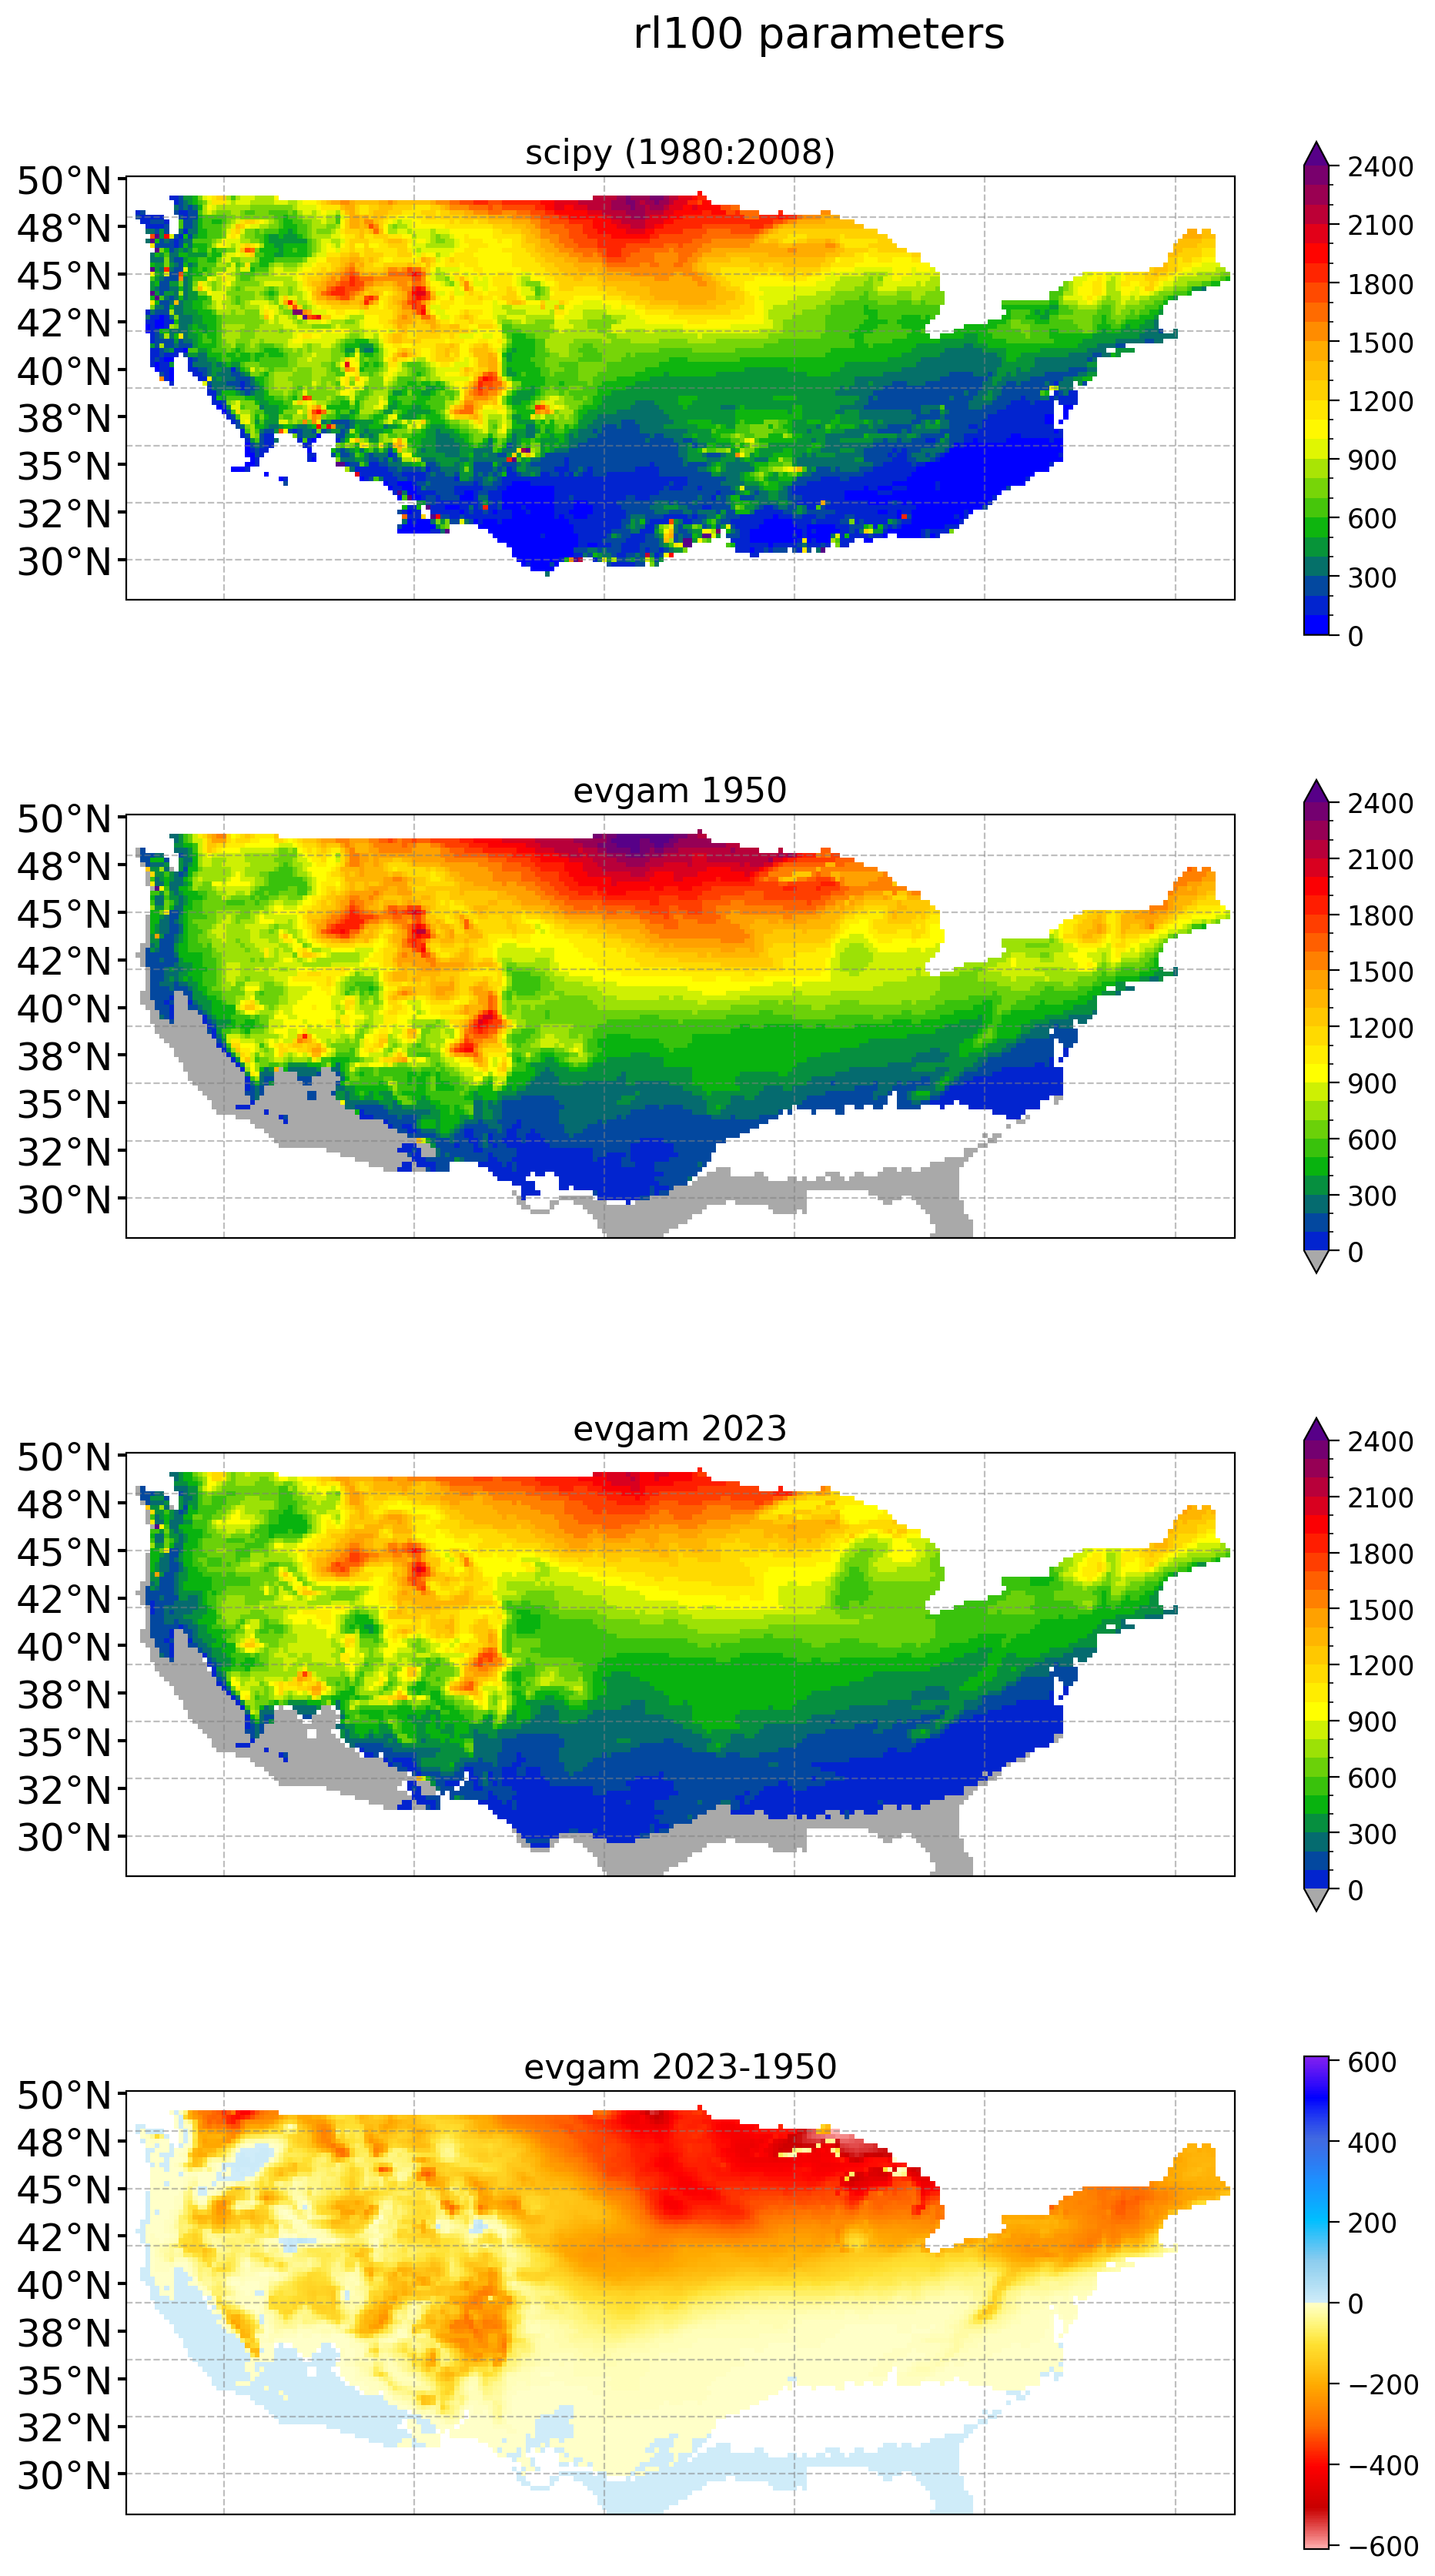

In [103]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(10,18),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.05,top=0.95, left=0.05,right=0.95,wspace=0.15,hspace=0.1)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,2500,100)

Srl100.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rrl100.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rrl100.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data.plot(ax=ax[3],cmap=cmaps.ncl_default_r,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.5, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 4: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('rl100 parameters',fontsize=20)    
outfile=f'GEV_NSloc_rl100.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.